# 1. Dataset Assessment

## Objetivo

Antes de iniciar el análisis exploratorio de datos (EDA), es necesario validar que el dataset seleccionado es adecuado para resolver el problema de negocio planteado.

En este notebook realizaremos una auditoría inicial del conjunto de datos para:

- Verificar su correcta carga.
- Comprender su estructura.
- Identificar las variables disponibles.
- Detectar posibles problemas de calidad.
- Evaluar la variable objetivo.
- Detectar posibles riesgos de data leakage.

Este análisis permitirá determinar si el dataset es adecuado para el desarrollo del modelo de Machine Learning.

# 2. Configuración del entorno de trabajo

## Objetivo

Importar las librerías necesarias para la carga, exploración y análisis inicial del dataset.

También se configuran algunas opciones de visualización para facilitar la lectura de los resultados durante el proyecto.

In [8]:
# Data manipulation
import pandas as pd
import numpy as np

# Paths and utilities
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 3. Carga del dataset

## Objetivo

Cargar el dataset utilizado en el proyecto y verificar que se encuentra correctamente accesible desde el entorno de trabajo.

### Fuente del dataset

Digital Marketing Performance Dataset

Fuente original:

https://www.kaggle.com/datasets/alinaboulsi/digital-marketing-performance-dataset

### Archivo local utilizado

Por motivos de reproducibilidad y rendimiento, el dataset se descarga previamente desde Kaggle y se almacena localmente dentro del directorio `data/`.

El notebook trabajará sobre la copia local del archivo CSV.

In [6]:
DATA_PATH = Path("../data/digital_marketing_dataset_30k.csv")

print("Dataset path:")
print(DATA_PATH)

print("\nFile exists:")
print(DATA_PATH.exists())

Dataset path:
..\data\digital_marketing_dataset_30k.csv

File exists:
True


In [26]:
# ==========================================================
# Load dataset
# ==========================================================

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 30,000
Columns: 35


In [27]:
# Quick validation

assert not df.empty, "Dataset is empty"

print("Dataset validation passed.")

Dataset validation passed.


# 4. Inspección inicial

## Objetivo

Antes de profundizar en el análisis del dataset es recomendable realizar una inspección visual inicial de los datos.

Esta revisión permite:

- Verificar que la carga se ha realizado correctamente.
- Identificar el formato general de las variables.
- Detectar posibles valores anómalos.
- Obtener una primera comprensión de la información disponible.

La inspección visual es una práctica habitual en proyectos de Data Science ya que permite detectar problemas que podrían pasar desapercibidos en un análisis puramente estadístico.

In [28]:
# ==========================================================
# First observations
# ==========================================================

print("=" * 60)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 60)

display(df.head())

# ==========================================================
# Last observations
# ==========================================================

print("\n")
print("=" * 60)
print("LAST 5 ROWS OF THE DATASET")
print("=" * 60)

display(df.tail())

# ==========================================================
# Random sample
# ==========================================================

print("\n")
print("=" * 60)
print("RANDOM SAMPLE OF 5 OBSERVATIONS")
print("=" * 60)

display(df.sample(5, random_state=42))

FIRST 5 ROWS OF THE DATASET


,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),is_weekend,is_weekend (text),country,market_tier,account,account_type,platform,placement,funnel_stage,objective,theme,campaign_id,campaign_name,ad_group_id,ad_group_name,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
0,08/04/2023,2023,4,Apr,14,Sat,7,Spring,0,No,1,Yes,Iraq,Tier 1,Travel_SkyTrip,Brand,TikTok,In-Feed,Awareness,Reach,Product Launch,C30853,Travel_SkyTrip_Product Launch_Awareness_TikTok...,AG412799,Product Launch_In-Feed_6,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610
1,28/04/2025,2025,4,Apr,18,Mon,12,Spring,0,No,0,No,Morocco,Tier 1,FMCG_Foodies,Brand,Meta,Feed,Awareness,Video Views,Seasonal,C49194,FMCG_Foodies_Seasonal_Awareness_Meta_Apr_2025,AG863446,Seasonal_Feed_42,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086
2,18/12/2024,2024,12,Dec,51,Wed,10,Winter,0,No,0,No,United Arab Emirates,Tier 1,Ecom_FashionCo,Brand,Google Display,Display,Conversion,Sales,UGC,C54438,Ecom_FashionCo_UGC_Conversion_Google Display_D...,AG769411,UGC_Display_2,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0
3,26/04/2024,2024,4,Apr,17,Fri,20,Spring,0,No,0,No,KSA,Tier 1,Ecom_ElectroHub,Brand,Snapchat,Stories,Consideration,Traffic,Educational,C60684,Ecom_ElectroHub_Educational_Consideration_Snap...,AG131656,Educational_Stories_49,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0
4,19/04/2024,2024,4,Apr,16,Fri,22,Spring,0,No,0,No,Bahrain,Tier 3,FMCG_Foodies,Brand,Meta,Reels,Awareness,Reach,Retargeting,C57210,FMCG_Foodies_Retargeting_Awareness_Meta_Apr_2024,AG633873,Retargeting_Reels_37,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160




LAST 5 ROWS OF THE DATASET


,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),is_weekend,is_weekend (text),country,market_tier,account,account_type,platform,placement,funnel_stage,objective,theme,campaign_id,campaign_name,ad_group_id,ad_group_name,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
29995,05/05/2023,2023,5,May,18,Fri,7,Spring,0,No,0,No,Iraq,Tier 1,Fintech_AppX,Brand,Google Search,Search,Conversion,Sales,UGC,C25573,Fintech_AppX_UGC_Conversion_Google Search_May_...,AG776741,UGC_Search_12,AD4737153,Search_V4,79.61,4255,1498,2.84,241,12,1192.40,0
29996,12/10/2025,2025,10,Oct,41,Sun,0,Fall,0,No,1,Yes,Iraq,Tier 1,FMCG_Foodies,Creator,Google Search,Search,Awareness,Video Views,Retargeting,C81668,FMCG_Foodies_Retargeting_Awareness_Google Sear...,AG335235,Retargeting_Search_2,AD3669074,Search_V2,779.14,85192,36862,2.31,5366,1,0.00,8459
29997,29/11/2023,2023,11,Nov,48,Wed,13,Fall,0,No,0,No,KSA,Tier 1,Travel_SkyTrip,Creator,TikTok,In-Feed,Consideration,Traffic,Promo,C76435,Travel_SkyTrip_Promo_Consideration_TikTok_Nov_...,AG440952,Promo_In-Feed_14,AD3415402,In-Feed_V6,115.51,12806,6948,1.84,181,0,0.00,2432
29998,23/03/2025,2025,3,Mar,12,Sun,4,Spring,0,No,1,Yes,KSA,Tier 1,FMCG_Foodies,Brand,Google Display,Display,Awareness,Reach,Educational,C20532,FMCG_Foodies_Educational_Awareness_Google Disp...,AG320612,Educational_Display_43,AD9044768,Display_V2,119.65,23541,14313,1.64,115,0,0.00,0
29999,28/07/2025,2025,7,Jul,31,Mon,10,Summer,0,No,0,No,Iraq,Tier 1,Ecom_ElectroHub,Brand,Google Search,Search,Awareness,Reach,Promo,C97617,Ecom_ElectroHub_Promo_Awareness_Google Search_...,AG648283,Promo_Search_6,AD3936589,Search_V4,475.92,20486,13082,1.57,746,0,0.00,0




RANDOM SAMPLE OF 5 OBSERVATIONS


,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),is_weekend,is_weekend (text),country,market_tier,account,account_type,platform,placement,funnel_stage,objective,theme,campaign_id,campaign_name,ad_group_id,ad_group_name,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
2308,04/12/2023,2023,12,Dec,49,Mon,9,Winter,0,No,0,No,Bahrain,Tier 3,FMCG_Foodies,Brand,TikTok,In-Feed,Conversion,Sales,Seasonal,C34794,FMCG_Foodies_Seasonal_Conversion_TikTok_Dec_2023,AG281840,Seasonal_In-Feed_2,AD6213996,In-Feed_V7,71.90,15328,7374,2.08,231,2,62.68,1656
22404,20/07/2025,2025,7,Jul,29,Sun,0,Summer,0,No,1,Yes,KSA,Tier 1,Education_Academy,Creator,Meta,Feed,Consideration,Engagement,Retargeting,C73586,Education_Academy_Retargeting_Consideration_Me...,AG901911,Retargeting_Feed_6,AD1321580,Feed_V9,22.73,2587,1146,2.26,26,0,0.00,0
23397,17/06/2025,2025,6,Jun,25,Tue,8,Summer,0,No,0,No,Oman,Tier 1,Travel_SkyTrip,Brand,Meta,Feed,Awareness,Video Views,Promo,C33026,Travel_SkyTrip_Promo_Awareness_Meta_Jun_2025,AG824583,Promo_Feed_30,AD5828750,Feed_V9,1010.36,198423,97192,2.04,2245,1,0.00,18703
25058,26/02/2025,2025,2,Feb,9,Wed,8,Winter,0,No,0,No,Iraq,Tier 1,Travel_SkyTrip,Brand,LinkedIn,Feed,Conversion,Sales,UGC,C31631,Travel_SkyTrip_UGC_Conversion_LinkedIn_Feb_2025,AG333946,UGC_Feed_38,AD4548946,Feed_V9,313.91,15407,6434,2.39,143,1,88.58,0
2664,24/08/2023,2023,8,Aug,34,Thu,7,Summer,0,No,0,No,KSA,Tier 1,FMCG_Foodies,Brand,TikTok,In-Feed,Consideration,Engagement,Seasonal,C77898,FMCG_Foodies_Seasonal_Consideration_TikTok_Aug...,AG617940,Seasonal_In-Feed_26,AD7905379,In-Feed_V2,183.02,26035,13053,1.99,235,0,0.00,3865


# 5. Estructura del dataset

## Objetivo

Comprender la estructura general del conjunto de datos antes de iniciar el análisis exploratorio.

En esta sección analizaremos:

- El tamaño del dataset.
- El número de variables disponibles.
- Los tipos de datos presentes.
- La estructura general de las columnas.

Esta información será fundamental para planificar las fases posteriores de limpieza, transformación y modelado.

In [29]:
# ==========================================================
# Dataset dimensions
# ==========================================================

rows, cols = df.shape

print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)

print(f"Rows: {rows:,}")
print(f"Columns: {cols}")

DATASET DIMENSIONS
Rows: 30,000
Columns: 35


In [30]:
# ==========================================================
# Dataset structure
# ==========================================================

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

df.info()

DATASET STRUCTURE
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               30000 non-null  str    
 1   year               30000 non-null  int64  
 2   month              30000 non-null  int64  
 3   month_name         30000 non-null  str    
 4   week               30000 non-null  int64  
 5   day_of_week        30000 non-null  str    
 6   post_hour          30000 non-null  int64  
 7   season             30000 non-null  str    
 8   is_holiday         30000 non-null  int64  
 9   is_holiday (text)  30000 non-null  str    
 10  is_weekend         30000 non-null  int64  
 11  is_weekend (text)  30000 non-null  str    
 12  country            30000 non-null  str    
 13  market_tier        30000 non-null  str    
 14  account            30000 non-null  str    
 15  account_type       30000 non-null  str    
 16  platform       

In [31]:
# ==========================================================
# Column names
# ==========================================================

print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

COLUMN NAMES
01. date
02. year
03. month
04. month_name
05. week
06. day_of_week
07. post_hour
08. season
09. is_holiday
10. is_holiday (text)
11. is_weekend
12. is_weekend (text)
13. country
14. market_tier
15. account
16. account_type
17. platform
18. placement
19. funnel_stage
20. objective
21. theme
22. campaign_id
23. campaign_name
24. ad_group_id
25. ad_group_name
26. ad_id
27. ad_name
28. spend
29. impressions
30. reach
31. frequency
32. clicks
33. conversions
34. revenue
35. video_views


In [23]:
# ==========================================================
# Data types summary
# ==========================================================

print("=" * 60)
print("DATA TYPES SUMMARY")
print("=" * 60)

df.dtypes.value_counts()


DATA TYPES SUMMARY


str        21
int64      11
float64     3
Name: count, dtype: int64

## Conclusiones preliminares

La inspección estructural del dataset permite extraer las siguientes conclusiones iniciales:

### Tamaño del dataset

El conjunto de datos contiene 30.000 observaciones y 35 variables, lo que proporciona una base suficientemente amplia para desarrollar y evaluar modelos de Machine Learning.

### Calidad estructural

No se observan valores nulos en la revisión inicial de la estructura, lo que sugiere una buena calidad de los datos y reduce la necesidad de imputaciones complejas.

### Diversidad de variables

El dataset combina variables:

- Temporales.
- Geográficas.
- Operativas.
- De comportamiento.
- De rendimiento.

Esta diversidad permitirá explorar múltiples relaciones con la variable objetivo.

### Variables duplicadas conceptualmente

Se identifican algunas variables representadas tanto en formato numérico como textual, por ejemplo:

- is_holiday / is_holiday (text)
- is_weekend / is_weekend (text)

Estas variables deberán evaluarse durante la fase de preprocesamiento para evitar redundancias.

### Próximos pasos

En la siguiente sección se analizará la calidad de los datos con mayor profundidad, incluyendo:

- Valores nulos.
- Duplicados.
- Variables constantes.
- Posibles anomalías.

# 6. Calidad inicial de los datos

## Objetivo

Evaluar la calidad general del dataset antes de iniciar el análisis exploratorio.

En esta sección analizaremos:

- Valores nulos.
- Registros duplicados.
- Variables constantes.
- Posibles problemas de consistencia.

La detección temprana de problemas de calidad ayuda a reducir errores durante las fases posteriores de modelado.


In [32]:
# ==========================================================
# Missing values
# ==========================================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

# ==========================================================
# Duplicate records
# ==========================================================

print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

# ==========================================================
# Constant variables
# ==========================================================

print("=" * 60)
print("CONSTANT VARIABLES")
print("=" * 60)

constant_columns = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print(constant_columns)


MISSING VALUES
DUPLICATE RECORDS
Duplicate rows: 0
CONSTANT VARIABLES
[]


## Conclusiones preliminares

La evaluación inicial de calidad muestra un dataset limpio.

### Valores nulos

No se detectaron valores nulos en ninguna de las variables analizadas.

### Registros duplicados

No se identificaron observaciones duplicadas dentro del conjunto de datos.

### Variables constantes

No existen variables con un único valor para todas las observaciones.

### Evaluación general

Desde una perspectiva estructural, el dataset presenta una calidad muy elevada y no requiere acciones inmediatas de limpieza.

No obstante, será necesario realizar análisis adicionales para identificar posibles redundancias, variables derivadas y riesgos de data leakage antes de proceder al modelado.

# 7. Identificación preliminar de variables

## Objetivo

Antes de construir cualquier modelo es necesario comprender qué tipo de información contiene cada variable y cuál podría ser su utilidad durante el proceso de predicción.

En esta sección clasificaremos las variables disponibles según su naturaleza y función dentro del negocio.

Los objetivos principales son:

- Identificar variables numéricas y categóricas.
- Detectar posibles variables objetivo.
- Identificar variables redundantes.
- Detectar posibles riesgos de data leakage.
- Comprender mejor la estructura lógica del dataset.

Esta clasificación servirá como base para las fases posteriores de preprocesamiento y modelado.

In [33]:
# ==========================================================
# Numerical variables
# ==========================================================

numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("=" * 60)
print("NUMERICAL VARIABLES")
print("=" * 60)

print(f"Total numerical variables: {len(numeric_features)}\n")

for col in numeric_features:
    print(f"- {col}")

# ==========================================================
# Categorical variables
# ==========================================================

categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("=" * 60)
print("CATEGORICAL VARIABLES")
print("=" * 60)

print(f"Total categorical variables: {len(categorical_features)}\n")

for col in categorical_features:
    print(f"- {col}")

# ==========================================================
# Categorical cardinality
# ==========================================================

print("=" * 60)
print("CATEGORICAL CARDINALITY")
print("=" * 60)

for col in categorical_features:
    print(f"{col}: {df[col].nunique()} unique values")


# ==========================================================
# Variables overview
# ==========================================================

variables_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "unique_values": [df[col].nunique() for col in df.columns]
})

# ==========================================================
# Variables with highest cardinality
# ==========================================================

print("=" * 60)
print("VARIABLES WITH HIGHEST CARDINALITY")
print("=" * 60)

display(
    variables_summary
    .sort_values(by="unique_values", ascending=False)
    .head(15)
)

# ==========================================================
# Variables with lowest cardinality
# ==========================================================

print("=" * 60)
print("VARIABLES WITH LOWEST CARDINALITY")
print("=" * 60)

display(
    variables_summary
    .sort_values(by="unique_values", ascending=True)
    .head(15)
)

NUMERICAL VARIABLES
Total numerical variables: 14

- year
- month
- week
- post_hour
- is_holiday
- is_weekend
- spend
- impressions
- reach
- frequency
- clicks
- conversions
- revenue
- video_views
CATEGORICAL VARIABLES
Total categorical variables: 21

- date
- month_name
- day_of_week
- season
- is_holiday (text)
- is_weekend (text)
- country
- market_tier
- account
- account_type
- platform
- placement
- funnel_stage
- objective
- theme
- campaign_id
- campaign_name
- ad_group_id
- ad_group_name
- ad_id
- ad_name
CATEGORICAL CARDINALITY
date: 1096 unique values
month_name: 12 unique values
day_of_week: 7 unique values
season: 4 unique values
is_holiday (text): 2 unique values
is_weekend (text): 2 unique values
country: 12 unique values
market_tier: 3 unique values
account: 7 unique values
account_type: 2 unique values
platform: 6 unique values
placement: 11 unique values
funnel_stage: 3 unique values
objective: 6 unique values
theme: 8 unique values
campaign_id: 25548 unique values

C:\Users\ggran\AppData\Local\Temp\ipykernel_42096\2656434685.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


,column,dtype,unique_values
25,ad_id,str,29956
23,ad_group_id,str,29496
21,campaign_id,str,25548
28,impressions,int64,25004
27,spend,float64,24027
29,reach,int64,21739
22,campaign_name,str,19192
33,revenue,float64,8744
34,video_views,int64,8607
31,clicks,int64,4279


VARIABLES WITH LOWEST CARDINALITY


,column,dtype,unique_values
11,is_weekend (text),str,2
10,is_weekend,int64,2
9,is_holiday (text),str,2
15,account_type,str,2
8,is_holiday,int64,2
1,year,int64,3
13,market_tier,str,3
18,funnel_stage,str,3
7,season,str,4
16,platform,str,6


## Observaciones preliminares

La revisión de la cardinalidad de las variables permite identificar distintos grupos de interés:

### Variables de alta cardinalidad

Las variables con miles de valores únicos suelen corresponder a identificadores o nombres específicos de campañas, anuncios o grupos de anuncios.

Estas variables deberán evaluarse cuidadosamente durante la fase de preprocesamiento, ya que podrían aportar poco valor predictivo o introducir ruido en el modelo.

### Variables de baja cardinalidad

Las variables con pocos valores únicos suelen representar categorías, segmentos o indicadores binarios.

Este tipo de variables suele ser especialmente útil para modelos de Machine Learning tras aplicar las transformaciones adecuadas.

### Próximos pasos

En la siguiente sección se analizará la variable objetivo (`revenue`) y se evaluarán posibles riesgos de data leakage derivados de variables de rendimiento como `clicks`, `conversions`, `reach` o `impressions`.

# 8. Evaluación preliminar del target

## Objetivo

Uno de los pasos más importantes en cualquier proyecto de Machine Learning es definir correctamente la variable objetivo (target).

La variable objetivo representa aquello que el modelo intentará predecir a partir del resto de variables disponibles.

En este proyecto, la principal candidata es la variable `revenue`, ya que representa el resultado económico generado por una campaña de marketing digital.

Antes de confirmar esta decisión será necesario:

- Analizar la distribución de la variable.
- Revisar sus estadísticas principales.
- Identificar posibles valores atípicos.
- Evaluar posibles riesgos de data leakage.

La correcta definición del target tendrá un impacto directo sobre la utilidad práctica del modelo y la validez de los resultados obtenidos.

In [38]:
# ==========================================================
# Target variable candidate
# ==========================================================

target = "revenue"

print("=" * 60)
print("TARGET VARIABLE CANDIDATE")
print("=" * 60)

print(f"Selected target candidate: {target}")

TARGET VARIABLE CANDIDATE
Selected target candidate: revenue


In [39]:
# ==========================================================
# Revenue descriptive statistics
# ==========================================================

print("=" * 60)
print("REVENUE DESCRIPTIVE STATISTICS")
print("=" * 60)

display(df[target].describe())

REVENUE DESCRIPTIVE STATISTICS


count    30000.00
mean       475.71
std       2814.17
min          0.00
25%          0.00
50%          0.00
75%         72.35
max     104733.41
Name: revenue, dtype: float64

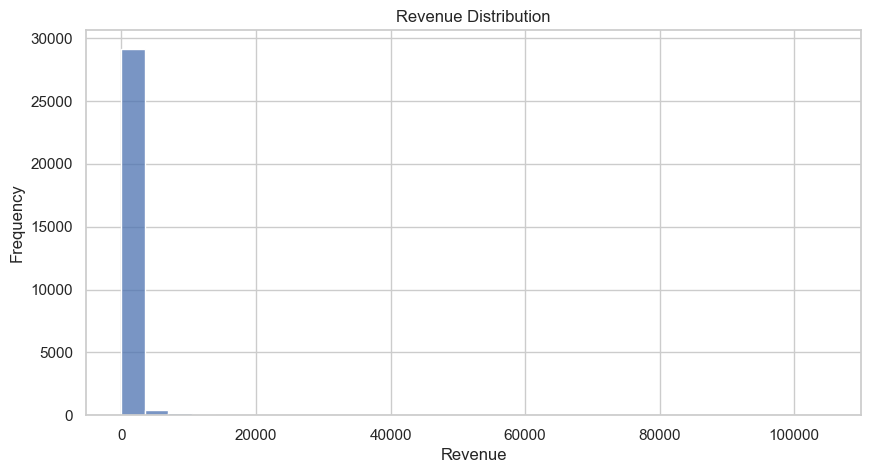

In [40]:
# ==========================================================
# Revenue distribution
# ==========================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x=target,
    bins=30
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

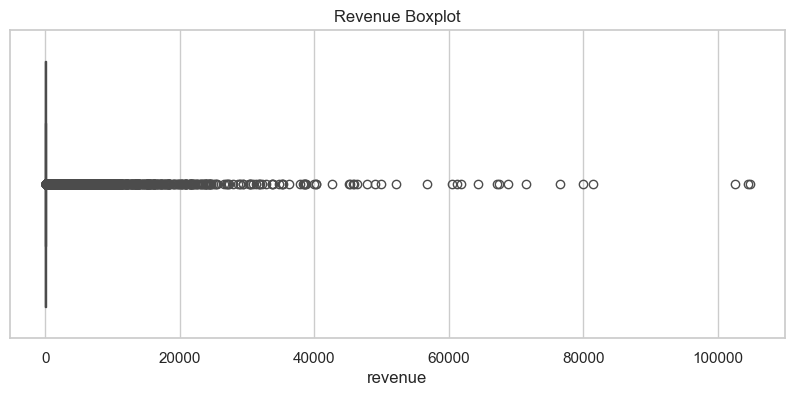

In [41]:
# ==========================================================
# Revenue boxplot
# ==========================================================

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df[target]
)

plt.title("Revenue Boxplot")

plt.show()

In [42]:
# ==========================================================
# Revenue range
# ==========================================================

print("=" * 60)
print("REVENUE RANGE")
print("=" * 60)

print(f"Minimum revenue: {df[target].min():,.2f}")
print(f"Maximum revenue: {df[target].max():,.2f}")
print(f"Average revenue: {df[target].mean():,.2f}")
print(f"Median revenue: {df[target].median():,.2f}")

REVENUE RANGE
Minimum revenue: 0.00
Maximum revenue: 104,733.41
Average revenue: 475.71
Median revenue: 0.00


## Conclusiones preliminares

La variable `revenue` presenta una distribución fuertemente asimétrica hacia la derecha.

### Hallazgos principales

- La mediana es igual a cero.
- Más del 50% de las observaciones no generan ingresos.
- Existen campañas con ingresos extremadamente elevados.
- La distribución contiene numerosos valores atípicos.

### Implicaciones para el modelado

La naturaleza de la variable objetivo sugiere que los modelos lineales simples podrían tener dificultades para capturar adecuadamente el comportamiento de los datos.

Será necesario evaluar algoritmos más robustos frente a distribuciones asimétricas y posibles transformaciones de la variable objetivo durante las fases de modelado.

### Próximos pasos

Antes de seleccionar el modelo definitivo se analizarán las relaciones entre las variables predictoras y la variable objetivo, así como posibles riesgos de data leakage.

# 9. Análisis preliminar de Data Leakage

## Objetivo

Uno de los riesgos más importantes en proyectos de Machine Learning es la presencia de data leakage.

El data leakage ocurre cuando el modelo tiene acceso a información que no estaría disponible en el momento real de realizar una predicción.

Esto puede producir métricas artificialmente elevadas durante el entrenamiento y evaluación del modelo, generando una falsa sensación de rendimiento.

En esta sección realizaremos una revisión preliminar de las variables disponibles para identificar posibles riesgos de fuga de información.

El objetivo es determinar qué variables podrían contener información directamente relacionada con la variable objetivo (`revenue`) y requerir una evaluación más profunda antes del modelado.

In [43]:
# ==========================================================
# Correlation with revenue
# ==========================================================

correlation_with_target = (
    df[numeric_features]
    .corr(numeric_only=True)["revenue"]
    .sort_values(ascending=False)
)

print("=" * 60)
print("CORRELATION WITH REVENUE")
print("=" * 60)

display(correlation_with_target)

CORRELATION WITH REVENUE


revenue        1.00
conversions    0.76
clicks         0.48
spend          0.19
impressions    0.10
frequency      0.08
reach          0.07
month          0.06
week           0.06
is_holiday     0.02
post_hour      0.01
year          -0.00
is_weekend    -0.02
video_views   -0.02
Name: revenue, dtype: float64

In [44]:
# ==========================================================
# Top correlations
# ==========================================================

top_corr = correlation_with_target.drop("revenue")

display(top_corr.head(10))

conversions   0.76
clicks        0.48
spend         0.19
impressions   0.10
frequency     0.08
reach         0.07
month         0.06
week          0.06
is_holiday    0.02
post_hour     0.01
Name: revenue, dtype: float64

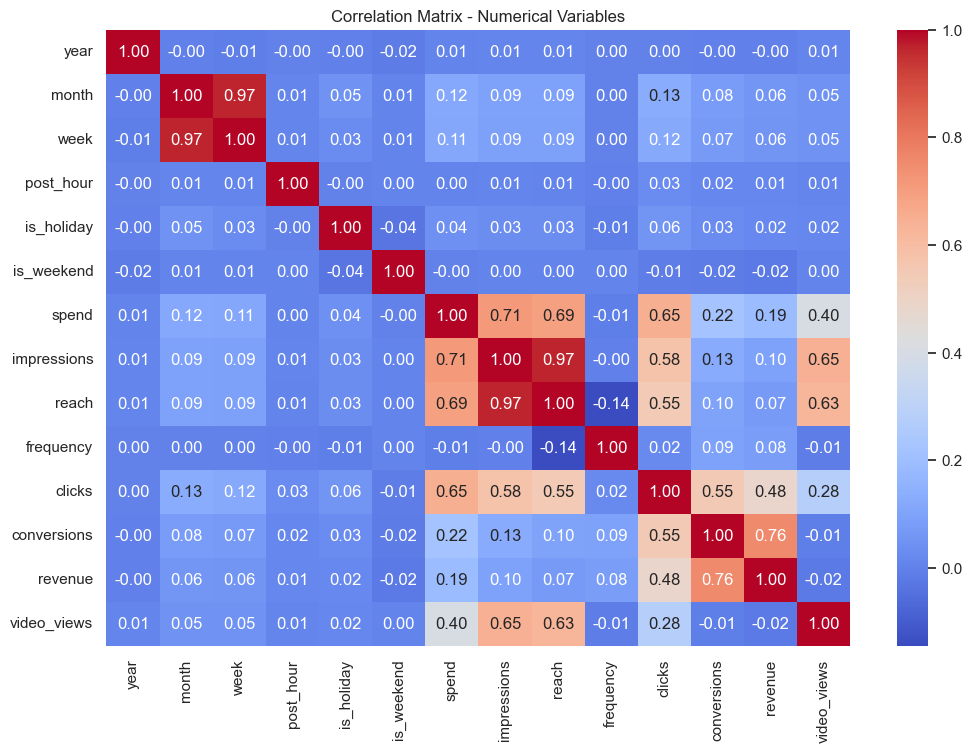

In [45]:
# ==========================================================
# Numerical variables heatmap
# ==========================================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix - Numerical Variables")

plt.show()

In [46]:
# ==========================================================
# Potential leakage candidates
# ==========================================================

potential_leakage = [
    "clicks",
    "conversions",
    "impressions",
    "reach",
    "video_views",
    "frequency",
    "spend"
]

display(
    correlation_with_target[
        correlation_with_target.index.isin(potential_leakage)
    ]
)

conversions    0.76
clicks         0.48
spend          0.19
impressions    0.10
frequency      0.08
reach          0.07
video_views   -0.02
Name: revenue, dtype: float64

## Conclusiones preliminares

El análisis de correlación permite identificar varias relaciones relevantes con la variable objetivo (`revenue`).

### Variables más relacionadas con Revenue

Las variables con mayor correlación observada son:

- conversions (0.76)
- clicks (0.48)
- spend (0.19)

Estas relaciones son coherentes desde una perspectiva de negocio y sugieren que el rendimiento de la campaña influye significativamente en los ingresos generados.

### Posibles riesgos de Data Leakage

No se detectan evidencias de leakage directo en esta fase.

Sin embargo, variables como:

- conversions
- clicks
- impressions
- reach
- video_views

representan información obtenida una vez que la campaña está en ejecución.

Su utilización futura dependerá del momento en que se pretenda realizar la predicción.

### Variables altamente correlacionadas

Se identifican algunos casos de alta correlación entre variables predictoras:

- month ↔ week
- impressions ↔ reach

Estas relaciones deberán revisarse durante la fase de selección de variables para evitar redundancias innecesarias.

### Conclusión general

El dataset no presenta evidencias claras de fuga de información en esta etapa del análisis.

No obstante, será necesario definir formalmente el alcance funcional del modelo antes de decidir qué variables podrán utilizarse durante el entrenamiento.

# 10. Conclusiones del Dataset Assessment

## Resumen ejecutivo

Durante esta fase se realizó una auditoría inicial del dataset con el objetivo de evaluar su calidad, estructura y adecuación para el desarrollo de un modelo de Machine Learning orientado a la predicción de ingresos en campañas de marketing digital.

El análisis permitió validar la consistencia del conjunto de datos, identificar posibles riesgos de modelado y establecer las primeras decisiones que guiarán el resto del proyecto.

---

## Hallazgos principales

### Calidad de los datos

El dataset presenta una **alta calidad estructural**:

* No se detectaron valores nulos.
* No se identificaron registros duplicados.
* No existen variables constantes.
* Todas las variables contienen información que, en esta fase preliminar, podría resultar útil para el análisis.

Estos resultados permiten iniciar las siguientes fases del proyecto sin necesidad de aplicar procesos intensivos de limpieza de datos.

---

### Estructura general

El conjunto de datos está compuesto por:

* **30.000 observaciones**
* **35 variables**

Las variables representan diferentes dimensiones relacionadas con campañas de marketing digital, incluyendo información:

* Temporal
* Geográfica
* Operativa
* Publicitaria
* De rendimiento
* Económica

Esta diversidad proporciona un contexto suficientemente rico para desarrollar modelos predictivos capaces de capturar relaciones complejas entre las características de una campaña y sus resultados económicos.

---

### Variable objetivo

La variable **`revenue`** se identifica como la principal candidata para actuar como variable objetivo dentro del problema de regresión.

El análisis preliminar muestra las siguientes características:

* Distribución altamente asimétrica.
* Mediana igual a cero.
* Presencia de valores extremos.
* Comportamiento consistente con escenarios reales de marketing digital, donde una parte importante de las campañas generan ingresos reducidos mientras que unas pocas concentran gran parte de la facturación.

Aunque esta distribución supondrá un reto durante el modelado, también aporta realismo al problema de negocio planteado.

---

### Variables con mayor asociación lineal

Las variables que presentan una mayor correlación lineal con los ingresos son:

| Variable    | Correlación |
| ----------- | ----------: |
| conversions |        0.76 |
| clicks      |        0.48 |
| spend       |        0.19 |

Estas relaciones son coherentes desde una perspectiva de negocio, ya que reflejan la conexión esperada entre la inversión publicitaria, la interacción de los usuarios y los resultados económicos obtenidos.

No obstante, la correlación no implica causalidad, por lo que estas asociaciones deberán validarse posteriormente mediante distintos modelos de Machine Learning. Estas variables constituyen las principales candidatas para aportar capacidad predictiva durante el entrenamiento de los modelos.

---

### Riesgo de Data Leakage

Durante la auditoría no se identificaron evidencias de fuga directa de información.

Sin embargo, algunas variables representan métricas generadas durante la ejecución o finalización de la campaña y podrían introducir información que no estaría disponible en un escenario real de predicción.

Entre ellas destacan:

* conversions
* clicks
* impressions
* reach
* video_views

Estas variables serán revisadas cuidadosamente durante la fase de Feature Engineering para decidir si deben mantenerse, transformarse o excluirse del modelo final.

---

### Variables potencialmente redundantes

Se identificaron relaciones de alta correlación entre algunos predictores, especialmente:

* month ↔ week
* impressions ↔ reach

Estas relaciones podrían introducir problemas de multicolinealidad en determinados algoritmos, por lo que serán evaluadas durante la fase de selección de variables y construcción del pipeline de preprocesamiento.

---

## Limitaciones identificadas

Aunque el dataset presenta una alta calidad estructural, se han identificado algunos aspectos que requerirán un análisis más profundo durante las siguientes fases del proyecto:

* Posible presencia de variables derivadas del resultado final de la campaña (riesgo de Data Leakage).
* Distribución altamente asimétrica de la variable objetivo.
* Presencia de valores extremos que podrían afectar al rendimiento de algunos algoritmos de regresión.
* Posible multicolinealidad entre variables altamente correlacionadas.
* Necesidad de analizar el comportamiento de las variables categóricas y definir su estrategia de codificación.

Estas limitaciones no comprometen la viabilidad del proyecto, pero deberán ser consideradas durante el diseño del modelo predictivo.

---

## Decisiones adoptadas

Tras completar la auditoría inicial del dataset se establecen las siguientes decisiones de trabajo:

* Utilizar **`revenue`** como variable objetivo provisional del proyecto.
* Mantener inicialmente todas las variables disponibles hasta finalizar el Exploratory Data Analysis (EDA).
* Posponer la eliminación de variables potencialmente redundantes hasta disponer de evidencia suficiente durante la fase de selección de variables.
* Revisar específicamente el riesgo de Data Leakage antes del entrenamiento definitivo de los modelos.
* Documentar todas las decisiones de preprocesamiento para garantizar la trazabilidad del proyecto.

---

## Impacto en el proyecto

La información obtenida durante esta auditoría permitirá orientar las siguientes fases del proyecto con un mayor nivel de confianza. Detectar de forma temprana aspectos como el posible Data Leakage, la distribución de la variable objetivo o la existencia de variables altamente correlacionadas reducirá el riesgo de introducir sesgos en el modelo y facilitará la construcción de un pipeline reproducible y mantenible.

Desde una perspectiva de ingeniería de Machine Learning, esta fase constituye un mecanismo de control de calidad previo al modelado y establece una base sólida para las decisiones técnicas que se adoptarán durante el resto del proyecto.

---

## Valor para el negocio

Desde una perspectiva de marketing digital, el dataset proporciona información suficiente para modelar la relación existente entre la inversión publicitaria, el comportamiento de la audiencia y los resultados económicos de las campañas.

Esto permitirá construir una herramienta capaz de estimar ingresos potenciales a partir de las características de una campaña, aportando valor como apoyo a la planificación, optimización y evaluación de estrategias de marketing.

---

## Conclusión técnica

La auditoría confirma que el dataset es adecuado para el desarrollo de un proyecto de Machine Learning basado en técnicas de regresión.

Su alta calidad estructural, el volumen de información disponible y la diversidad de variables proporcionan una base sólida para desarrollar un modelo predictivo robusto y evaluar diferentes algoritmos supervisados.

Las limitaciones detectadas han sido identificadas de forma temprana y serán abordadas de manera sistemática durante las siguientes fases del proyecto.

En conjunto, esta fase establece una línea base objetiva sobre la calidad y las características del conjunto de datos, reduciendo la incertidumbre antes de iniciar el análisis exploratorio y proporcionando trazabilidad para las decisiones técnicas que se adopten durante el resto del proyecto.

---

## Próximas etapas

Con la fase de auditoría completada, el proyecto continuará con las siguientes actividades:

1. Realizar el Exploratory Data Analysis (EDA) completo.
2. Analizar la distribución de las variables y detectar patrones relevantes.
3. Diseñar el pipeline de preprocesamiento.
4. Definir la estrategia de selección de variables.
5. Implementar y comparar distintos algoritmos de regresión.
6. Evaluar el rendimiento mediante métricas apropiadas y validación cruzada.

---

## Cierre de la fase

La auditoría inicial confirma que el dataset reúne las condiciones necesarias para **justificar** el inicio de la fase de **Exploratory Data Analysis (EDA)**.

Las decisiones adoptadas durante esta etapa constituyen la base sobre la que se desarrollarán el preprocesamiento de datos, la selección de variables y la construcción de los modelos predictivos.

Con ello se da por finalizada la fase **Dataset Assessment**, dejando el proyecto preparado para iniciar el análisis exploratorio en profundidad.
